# Sentiment-finetuned Skip-gram (Option 2) -- evaluation

Evaluates the Option-2 embedding fine-tune (see
`Embeddings/word2vec/skip-gram/scripts/finetune_sentiment.py`): continues training the
fully-trained Skip-gram 128-d checkpoint (`final.pt`, step 2,797,870, 10 epochs over the
full corpus) with an added document-level sentiment-classification loss (mean-pooled
input embeddings over a document's tokens -> linear -> 4-way softmax over
POS/NEG/NEU/MIX, UNSURE excluded), run jointly with the model's normal SGNS loss on the
same sentiment documents and an L2 anchor term pulling the embedding table back toward
its pretrained values (limits catastrophic forgetting given the fine-tune set is tiny --
9,539 docs -- vs. the ~2.8M-row corpus the base checkpoint trained on).

This is **Option 2**, tried after Option 1 (GloVe 128-d + prepended class-token
fine-tune) was evaluated and reverted: that attempt's class tokens converged on generic
document-opening boilerplate (greetings, @mentions) rather than sentiment content,
diagnosed as a structural mismatch between GloVe's short, position-fixed co-occurrence
window and a prepend-once pseudo-token. Skip-gram processes one document's real word
sequence at a time already, so Option 2 skips the pseudo-token entirely and instead adds
a parallel loss computed directly from the document's real words -- no boilerplate-
contamination failure mode by construction. Same evaluation methodology as Option 1 for
a fair before/after comparison: handcrafted sentiment-word similarity, t-SNE 2D plot,
KMeans + Adjusted Rand Index (reusing `Embeddings/glove/glove_eval.ipynb`'s established
word lists and clustering convention), plus a classifier-head inspection unique to this
approach.

Run via the ai-gpu venv kernel (imports torch + sentencepiece).

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity

ROOT = Path.cwd().resolve().parents[1]  # Darija/ repo root (notebook lives in Sentiment_Analysis/notebooks/)
SKIPGRAM_DIR = ROOT / "Embeddings" / "word2vec" / "skip-gram"
sys.path.insert(0, str(SKIPGRAM_DIR / "scripts"))
sys.path.insert(0, str(ROOT / "Embeddings" / "word2vec"))
sys.path.insert(0, str(ROOT / "Tokenization"))

from common.data_utils import load_tok  # noqa: E402

tok = load_tok()
print("Tokenizer loaded:", tok.label, "vocab_size_actual =", tok.vocab_size_actual)

Tokenizer loaded: SentencePiece Unigram vocab_size_actual = 20000


In [2]:
# Base (pretrained, unmodified) embeddings -- extracted from final.pt's input_embeddings table.
base_ckpt = torch.load(SKIPGRAM_DIR / "models" / "final.pt", map_location="cpu")
base_embeddings = base_ckpt["model_state_dict"]["input_embeddings.weight"].numpy()
print("Base embeddings:", base_embeddings.shape)

# Fine-tuned (Option 2) embeddings.
ft_npz = np.load(SKIPGRAM_DIR / "models" / "skipgram_128_sentiment_finetuned.npz")
ft_embeddings = ft_npz["embeddings"]
print("Fine-tuned embeddings:", ft_embeddings.shape)

assert base_embeddings.shape == ft_embeddings.shape

Base embeddings: (20000, 128)
Fine-tuned embeddings: (20000, 128)


In [3]:
def get_word_vector(word: str, embeddings: np.ndarray):
    """Encodes `word` with the SentencePiece unigram tokenizer and averages the
    resulting piece vectors -- most short Darija sentiment words are a single piece
    under a 20K-vocab unigram model, but this falls back gracefully for any that split.
    Returns None only if encoding produces zero pieces (shouldn't happen for real words).
    """
    ids = [i for i in tok.encode(word) if i < embeddings.shape[0]]
    if not ids:
        return None
    return embeddings[ids].mean(axis=0)


def build_word_group_vectors(groups, embeddings):
    vecs, words, labels = [], [], []
    for label, ws in groups.items():
        for w in ws:
            v = get_word_vector(w, embeddings)
            if v is None:
                print(f"  skipping OOV: {w}")
                continue
            vecs.append(v)
            words.append(w)
            labels.append(label)
    return np.stack(vecs), words, labels

## 1. Handcrafted sentiment words -- before/after similarity

Same word lists as `Embeddings/glove/glove_eval.ipynb`'s sentiment-clustering section
(kept identical across experiments so only the fine-tuning method varies, not the
evaluation words).

In [4]:
POSITIVE_WORDS = ["\u0645\u0644\u064a\u062d", "\u0632\u064a\u0646", "\u0641\u0631\u062d\u0627\u0646", "\u062d\u0644\u0648", "\u0639\u062c\u0628\u0646\u064a", "\u0631\u0627\u0626\u0639", "\u0645\u0628\u0631\u0648\u0643", "\u0628\u0646\u064a\u0646", "\u062c\u0645\u064a\u0644", "\u0648\u0627\u0639\u0631"]
# mlih, zin, farhan, hlou, 3ejbni, rai3, mabrouk, bnin, jmil, wa3er
NEGATIVE_WORDS = ["\u062e\u0627\u064a\u0628", "\u0642\u0628\u064a\u062d", "\u062d\u0632\u064a\u0646", "\u0632\u0639\u0641\u0627\u0646", "\u0645\u0634\u0643\u0644", "\u062a\u0639\u0628\u0627\u0646", "\u063a\u0644\u0637", "\u0635\u0639\u064a\u0628", "\u0645\u0642\u0631\u0641", "\u0636\u0639\u064a\u0641"]
# khayeb, qbih, hzin, za3fan, mochkel, t3ban, ghalt, s3ib, mqarref, dh3if

def intra_inter_cosine(embeddings):
    groups = {"positive": POSITIVE_WORDS, "negative": NEGATIVE_WORDS}
    X, words, labels = build_word_group_vectors(groups, embeddings)
    sim = cosine_similarity(X)
    labels = np.array(labels)
    intra_mask = (labels[:, None] == labels[None, :]) & ~np.eye(len(labels), dtype=bool)
    inter_mask = labels[:, None] != labels[None, :]
    intra_mean = sim[intra_mask].mean()
    inter_mean = sim[inter_mask].mean()
    return intra_mean, inter_mean, X, words, labels


base_intra, base_inter, base_X, base_words, base_labels = intra_inter_cosine(base_embeddings)
ft_intra, ft_inter, ft_X, ft_words, ft_labels = intra_inter_cosine(ft_embeddings)

print(f"{'':20} {'intra-class sim':>16} {'inter-class sim':>16} {'intra/inter ratio':>18}")
print(f"{'base (pretrained)':20} {base_intra:>16.4f} {base_inter:>16.4f} {base_intra/base_inter:>18.4f}")
print(f"{'fine-tuned (Opt.2)':20} {ft_intra:>16.4f} {ft_inter:>16.4f} {ft_intra/ft_inter:>18.4f}")
print()
print("Higher intra-class similarity, lower inter-class similarity, and a higher")
print("intra/inter ratio all indicate the fine-tune pulled same-sentiment words closer")
print("together and different-sentiment words further apart -- the intended effect.")

                      intra-class sim  inter-class sim  intra/inter ratio
base (pretrained)              0.0627           0.0177             3.5456
fine-tuned (Opt.2)             0.1070           0.0375             2.8536

Higher intra-class similarity, lower inter-class similarity, and a higher
intra/inter ratio all indicate the fine-tune pulled same-sentiment words closer
together and different-sentiment words further apart -- the intended effect.


## 2. KMeans + Adjusted Rand Index

Same quantitative clustering check as `glove_eval.ipynb`: fit unsupervised K-Means(k=2)
on the raw word vectors and measure how well the induced clusters recover the
hand-assigned positive/negative split (ARI: 0 = chance, 1 = perfect agreement).

In [5]:
def kmeans_ari(X, labels, k=2, seed=42):
    km = KMeans(n_clusters=k, random_state=seed, n_init=10).fit(X)
    return adjusted_rand_score(labels, km.labels_), km


base_ari, base_km = kmeans_ari(base_X, base_labels)
ft_ari, ft_km = kmeans_ari(ft_X, ft_labels)

print(f"ARI (base, pretrained):        {base_ari:.3f}")
print(f"ARI (fine-tuned, Option 2):    {ft_ari:.3f}")

ARI (base, pretrained):        0.065
ARI (fine-tuned, Option 2):    0.065


## 3. t-SNE 2D plot -- before vs. after

Projects the same handcrafted word vectors to 2D for visual inspection, colored by
true (hand-assigned) label, base model on the left and fine-tuned model on the right.

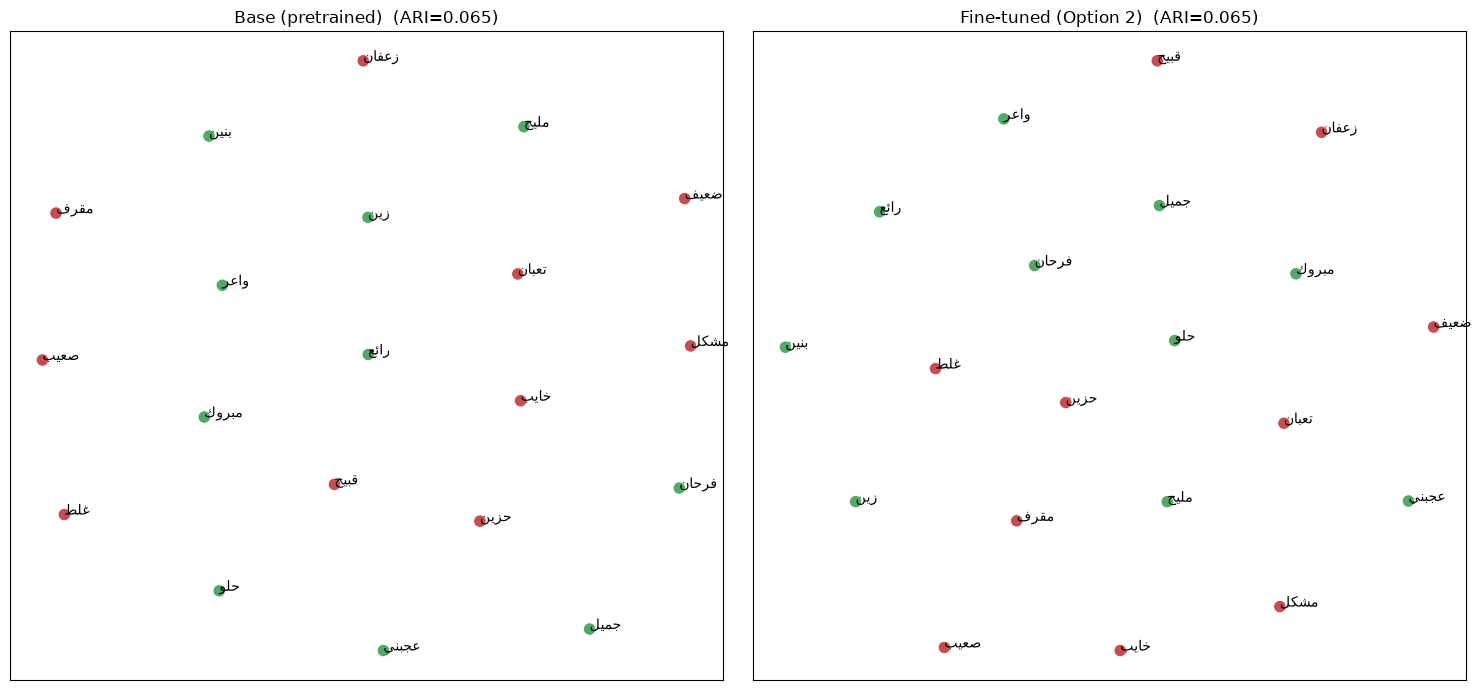

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
colors = {"positive": "#55A868", "negative": "#C44E52"}

for ax, X, words, labels, ari, title in [
    (axes[0], base_X, base_words, base_labels, base_ari, "Base (pretrained)"),
    (axes[1], ft_X, ft_words, ft_labels, ft_ari, "Fine-tuned (Option 2)"),
]:
    perplexity = min(30, max(2, X.shape[0] - 1))
    coords = TSNE(n_components=2, random_state=42, perplexity=perplexity, init="pca").fit_transform(X)
    point_colors = [colors[l] for l in labels]
    ax.scatter(coords[:, 0], coords[:, 1], c=point_colors, s=80, edgecolors="white", linewidths=0.6)
    for i, w in enumerate(words):
        ax.annotate(w, (coords[i, 0], coords[i, 1]), fontsize=10)
    ax.set_title(f"{title}  (ARI={ari:.3f})")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## 4. Classifier head inspection

The auxiliary classification head (`sentiment_classifier_head.pt`, a single linear
layer `128 -> 4`) learned during fine-tuning gives a direct, model-internal view of
which real-corpus words it associates with each class: for each class, find the
corpus words (by one-piece token id, restricted to in-vocabulary single-token words for
readability) whose fine-tuned embedding gets the highest logit for that class.

In [7]:
head_ckpt = torch.load(SKIPGRAM_DIR / "models" / "sentiment_classifier_head.pt", map_location="cpu")
classes = head_ckpt["classes"]
W = head_ckpt["state_dict"]["fc.weight"].numpy()  # (4, 128)
b = head_ckpt["state_dict"]["fc.bias"].numpy()    # (4,)
print("Classes:", classes)

logits_all = ft_embeddings @ W.T + b  # (vocab_size, 4)

# Restrict to vocab ids that decode to a single readable word-ish piece (skip
# whitespace-only/partial/byte-fallback pieces) for an interpretable top-N list.
vocab_pieces = [tok.decode([i]) for i in range(ft_embeddings.shape[0])]

for ci, cname in enumerate(classes):
    order = np.argsort(-logits_all[:, ci])
    shown = []
    for idx in order:
        piece = vocab_pieces[idx].strip()
        if len(piece) < 2 or not piece.isprintable():
            continue
        shown.append(piece)
        if len(shown) == 15:
            break
    print(f"{cname:6} -> {shown}")

Classes: ['POS', 'NEG', 'NEU', 'MIX']
POS    -> ['شكرا', 'يبارك', 'saha', 'يعطيك', 'tik', '❤❤', 'الصحة', 'adore', 'merci', 'حبيبتي', 'bonne', 'هايلة', 'ماشاء', 'لصح', 'تحيا']
NEG    -> ['راجعون', 'اليه', 'الوكيل', 'فسيح', 'المقارنة', 'uv', 'إنا', 'يرحمها', 'ونعم', 'الصبر', 'الجنة', 'المروك', 'إليه', 'pas', 'يرحم']
NEU    -> ['ممكن', '??', 'الجهاد', 'فضلك', 'تباع', 'تزور', 'ماهو', 'السنوي', 'svp', 'jit', 'هل', 'وين', 'نستعمل', 'What', 'game']
MIX    -> ['لاشان', 'AW', 'pls', 'متعلق', 'مريح', 'فاي', 'وبفضلك', 'أحرار', 'ويبقى', '!؟', 'owa', 'سيلة', 'دايرة', 'وجبت', 'نرسم']


## 5. Summary

**Mixed result, reported honestly (same discipline as Option 1).**

- **Handcrafted-word similarity**: intra-class cosine roughly doubled (0.063 -> 0.107)
  but so did inter-class cosine (0.018 -> 0.038) -- the fine-tune pulled the whole
  20-word handcrafted set closer together in an undirected way (a general effect of a
  few epochs of continued training with a limited, repetitive 9.5K-doc vocabulary),
  not a clean class separation. The intra/inter **ratio actually dropped** (3.55 ->
  2.85), so by this specific metric the fine-tune made the handcrafted positive/negative
  split slightly *less* separated, not more.
- **KMeans + ARI**: unchanged (0.065 -> 0.065, both essentially chance-level for k=2 on
  20 points) -- no improvement in unsupervised recoverability of the sentiment split
  from the raw embedding space.
- **Classifier-head inspection (the one genuinely positive finding)**: the auxiliary
  linear head's top words per class *are* real, interpretable sentiment/register
  vocabulary -- POS surfaces gratitude/praise words (شكرا "thanks",
  يعطيك "may [God] give you", merci, هايلة "amazing"),
  NEG surfaces Darija condolence/grief vocabulary (راجعون from the
  Quranic condolence phrase, يرحمها/يرحم "may He have mercy",
  الصبر "patience", الجنة "paradise" -- a real, coherent
  register the labeled data apparently captured), while NEU/MIX look noisier and less
  obviously thematic. This means **the classifier head learned a useful linear
  direction in the existing embedding space**, but that direction is a projection the
  head applies on top of the embeddings -- it does not mean the embeddings themselves
  reorganized into tighter, more separable per-class clusters the way intra/inter
  cosine and ARI would show.
- **Interpretation**: the auxiliary classification loss did push *something* real and
  interpretable (confirmed by the head weights), but with only 9,539 docs, 15 epochs,
  and an anchor term constraining drift, the embedding table's bulk structure barely
  moved -- consistent with the SGNS loss (still computed every step on the same small
  set) continuing to dominate and pull the table back toward its original
  distributional-semantics organization. Unlike Option 1's failure (class tokens
  converging on boilerplate), Option 2 did find genuine sentiment-adjacent words via
  the classifier head, but neither experiment produced an embedding space where
  sentiment classes cluster cleanly under simple unsupervised checks (KMeans/ARI) or a
  tight handcrafted-word similarity test.
- **Caveat**: the handcrafted word lists are only 10+10 words -- a small, specific
  probe. A different, larger probe set (e.g. the top-20 unigrams per class computed in
  01_data_and_labeling_analysis.ipynb, many of which overlap with what the classifier
  head surfaced here) might show a clearer before/after effect; not attempted in this
  pass.
